In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [31]:
df=pd.read_csv("vgsales.csv.zip")

This is a data about the video game sales of VG company


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


Data contains the game name,PLatform, Year,Genre, Publisher,North America sales,europe union sales , japan sales and rest world sales

In [4]:
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [7]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


This is to find the missing values in data frame

In [5]:
genre_df=df["Genre"].value_counts()
print(genre_df)


Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64


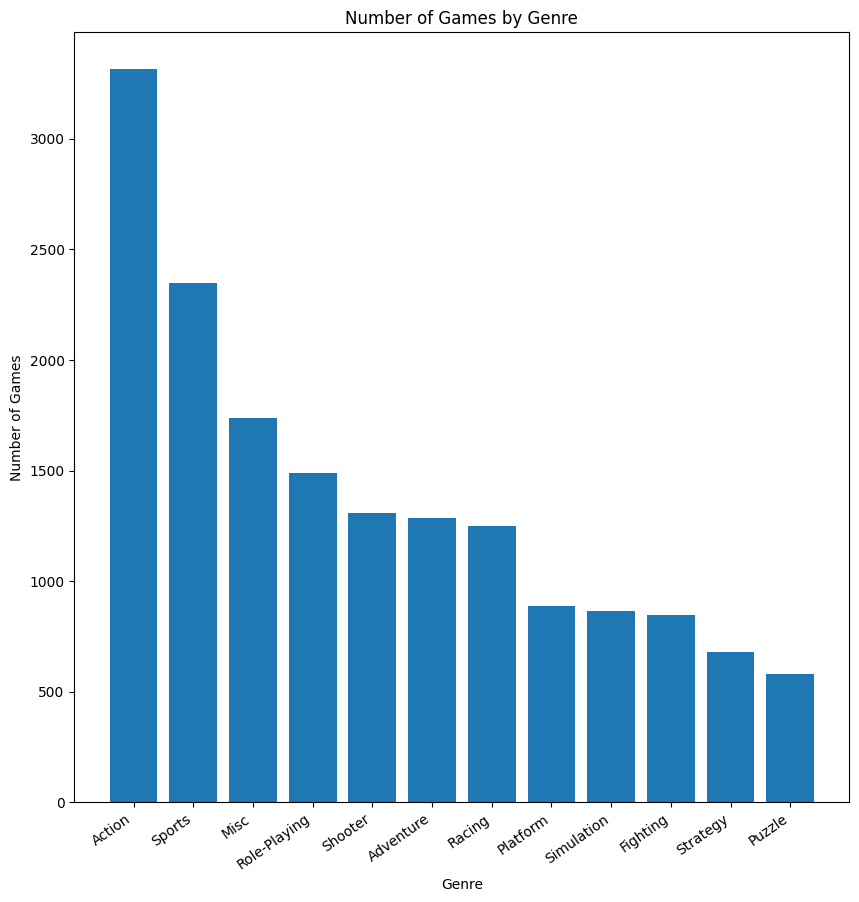

In [ ]:

plt.figure(figsize=(10,10))
plt.bar(genre_df.index,genre_df.values)
plt.xticks(rotation=35,ha='right')
plt.xlabel('Genre')
plt.ylabel('Number of Games')
plt.title('Number of Games by Genre')
plt.show()


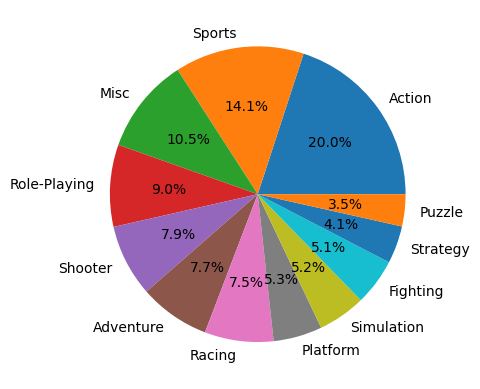

In [ ]:
plt.pie(genre_df.values,labels=genre_df.index,autopct='%1.1f%%')
plt.show()

In video game sales major(20%) sales belong to Action genre,followed by sports,miscellaneous,Role-Playing,Shooter,Adventure,Racing

In [ ]:
pub_df=df["Publisher"].value_counts()
pub_df=pub_df.reset_index()
print(pub_df)


                        Publisher  count
0                 Electronic Arts   1351
1                      Activision    975
2              Namco Bandai Games    932
3                         Ubisoft    921
4    Konami Digital Entertainment    832
..                            ...    ...
573           Media Entertainment      1
574           New World Computing      1
575                   Genterprise      1
576                    Rain Games      1
577             UIG Entertainment      1

[578 rows x 2 columns]


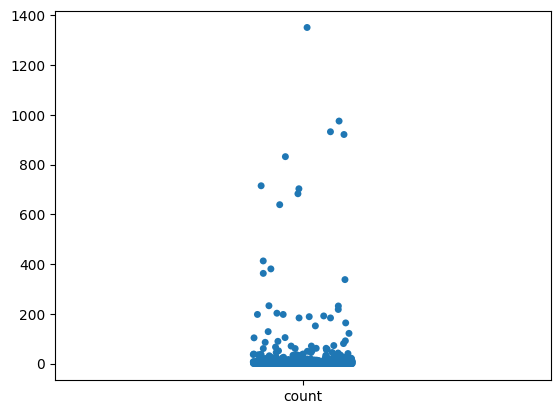

In [ ]:
sns.stripplot(data=pub_df)
plt.show()

They are over 578 publisher but we consider publishers who has released atleast 100 games

In [ ]:
publish_mod=pub_df[pub_df["count"] >= 100]
print(publish_mod)

                                 Publisher  count
0                          Electronic Arts   1351
1                               Activision    975
2                       Namco Bandai Games    932
3                                  Ubisoft    921
4             Konami Digital Entertainment    832
5                                      THQ    715
6                                 Nintendo    703
7              Sony Computer Entertainment    683
8                                     Sega    639
9                     Take-Two Interactive    413
10                                  Capcom    381
11                                   Atari    363
12                              Tecmo Koei    338
13                             Square Enix    233
14  Warner Bros. Interactive Entertainment    232
15              Disney Interactive Studios    218
16                                 Unknown    203
17                       Eidos Interactive    198
18                            Midway Games    198


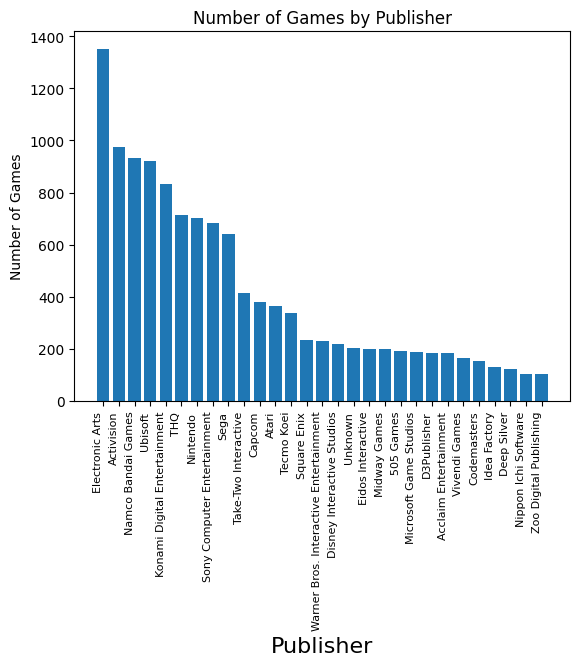

In [ ]:
plt.bar(publish_mod["Publisher"],publish_mod["count"])
plt.xticks(rotation=90,ha='right',fontsize=8)
plt.xlabel('Publisher',fontsize=16)
plt.ylabel('Number of Games')
plt.title('Number of Games by Publisher')
plt.show()

Electrinic arts released highest games(1351) followed by mactivision,Namco bandai games,ubisoft etc...

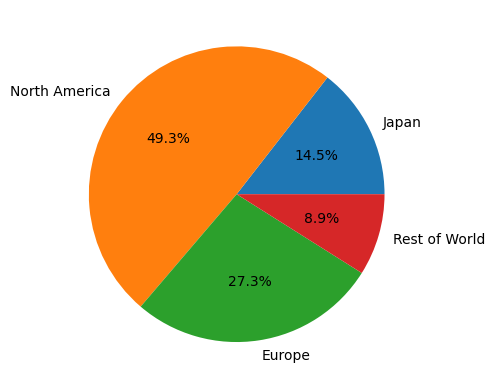

            name  total_sales
0          Japan      1291.02
1  North America      4392.95
2         Europe      2434.13
3  Rest of World       797.75


In [ ]:
sales_df=pd.DataFrame()
Japan_total=df["JP_Sales"].sum()
NA_total=df["NA_Sales"].sum()
EU_total=df["EU_Sales"].sum()
Rest_total=df["Other_Sales"].sum()
sales_df["name"]=["Japan","North America","Europe","Rest of World"]
sales_df["total_sales"]=[Japan_total,NA_total,EU_total,Rest_total]
plt.pie(sales_df["total_sales"],labels=sales_df["name"],autopct='%1.1f%%')
plt.show()
print(sales_df)

North america has major portion video game sales ~50% followed by europe, japan

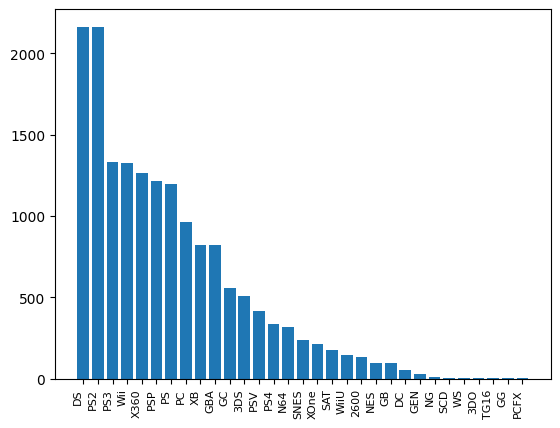

   Platform  count
0        DS   2163
1       PS2   2161
2       PS3   1329
3       Wii   1325
4      X360   1265
5       PSP   1213
6        PS   1196
7        PC    960
8        XB    824
9       GBA    822
10       GC    556
11      3DS    509
12      PSV    413
13      PS4    336
14      N64    319
15     SNES    239
16     XOne    213
17      SAT    173
18     WiiU    143
19     2600    133
20      NES     98
21       GB     98
22       DC     52
23      GEN     27
24       NG     12
25      SCD      6
26       WS      6
27      3DO      3
28     TG16      2
29       GG      1
30     PCFX      1


In [ ]:
platform_df=df["Platform"].value_counts()
platform_df=platform_df.reset_index()
plt.bar(platform_df["Platform"],platform_df["count"])
plt.xticks(rotation=90,ha='right',fontsize=8)
plt.show()
print(platform_df)


Video games related to DS,PS2 platform are sold more, followed by PS3,Wii,X360,PSP,PS platforms

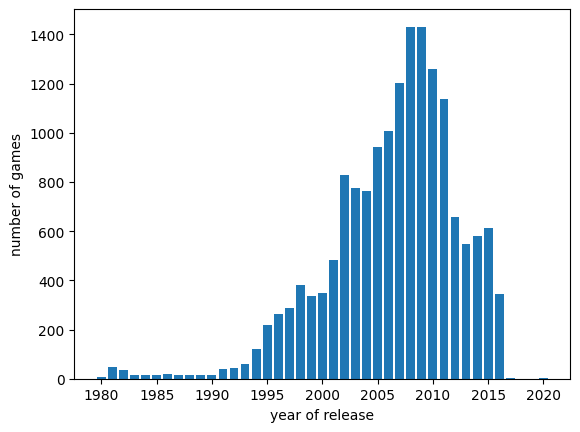

      Year  count
0   2009.0   1431
1   2008.0   1428
2   2010.0   1259
3   2007.0   1202
4   2011.0   1139
5   2006.0   1008
6   2005.0    941
7   2002.0    829
8   2003.0    775
9   2004.0    763
10  2012.0    657
11  2015.0    614
12  2014.0    582
13  2013.0    546
14  2001.0    482
15  1998.0    379
16  2000.0    349
17  2016.0    344
18  1999.0    338
19  1997.0    289
20  1996.0    263
21  1995.0    219
22  1994.0    121
23  1993.0     60
24  1981.0     46
25  1992.0     43
26  1991.0     41
27  1982.0     36
28  1986.0     21
29  1989.0     17
30  1983.0     17
31  1987.0     16
32  1990.0     16
33  1988.0     15
34  1985.0     14
35  1984.0     14
36  1980.0      9
37  2017.0      3
38  2020.0      1


In [ ]:
time_df=df["Year"].value_counts()
time_df=time_df.reset_index()
plt.bar(time_df["Year"],time_df["count"])
plt.xlabel("year of release")
plt.ylabel("number of games")
plt.show()
print(time_df)

In time period of 2007-2011 more number of ganmes released

Genre
Role-Playing    350.29
Action          158.65
Sports          134.76
Platform        130.65
Misc            106.67
Fighting         87.15
Simulation       63.54
Puzzle           56.68
Racing           56.61
Adventure        51.99
Strategy         49.10
Shooter          38.18
Name: JP_Sales, dtype: float64


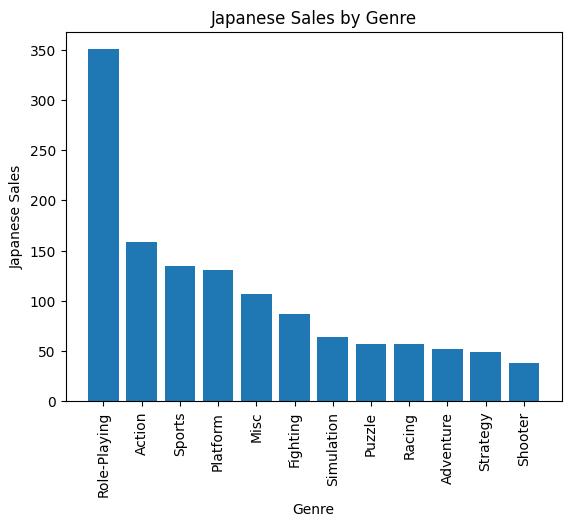

In [6]:
genre_sales_japan = df.groupby("Genre")["JP_Sales"].sum()
genre_sales_japan = genre_sales.sort_values(ascending=False)
print(genre_sales_japan)

plt.bar(genre_sales_japan.index, genre_sales_japan.values)
plt.xticks(rotation=90)
plt.xlabel("Genre")
plt.ylabel("Japanese Sales")
plt.title("Japanese Sales by Genre")
plt.show()

Japan people are more willing to buy Role-PLaying genre video games followed by Action ,Sports ,platform genre games

Genre
Action          861.77
Sports          670.09
Shooter         575.16
Platform        445.99
Misc            396.92
Racing          356.93
Role-Playing    326.50
Fighting        220.74
Simulation      181.78
Puzzle          122.01
Adventure       101.93
Strategy         67.83
Name: NA_Sales, dtype: float64


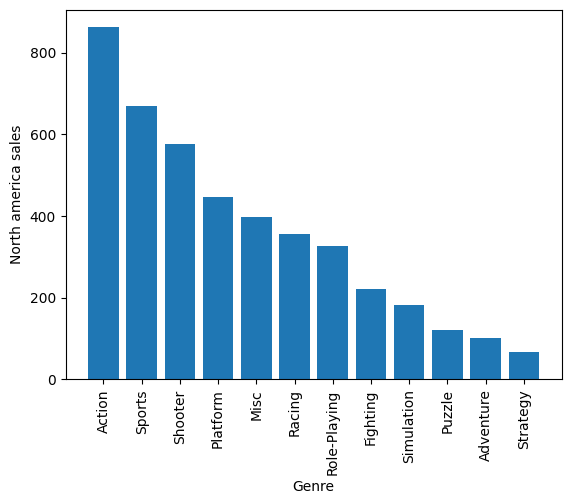

In [8]:
genre_sales_NA=df.groupby("Genre")["NA_Sales"].sum()
genre_sales_NA=genre_sales_NA.sort_values(ascending=False)
print(genre_sales_NA)
plt.bar(genre_sales_NA.index,genre_sales_NA.values)
plt.xticks(rotation=90)
plt.xlabel("Genre")
plt.ylabel("North america sales")
plt.show()

North america people more willing to buy Action genre video games followed by sports,shooter,platform genre games

Genre
Action          516.48
Sports          371.34
Shooter         310.45
Racing          236.31
Misc            211.77
Platform        200.65
Role-Playing    187.57
Simulation      113.02
Fighting        100.00
Adventure        63.74
Puzzle           50.52
Strategy         44.84
Name: EU_Sales, dtype: float64


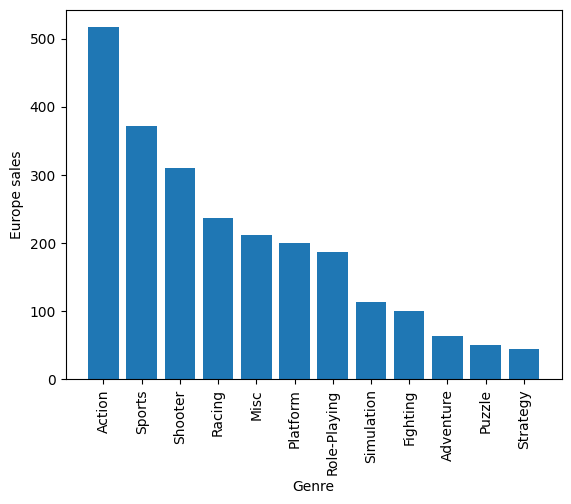

In [9]:
genre_sales_EU=df.groupby("Genre")["EU_Sales"].sum()
genre_sales_EU=genre_sales_EU.sort_values(ascending=False)
print(genre_sales_EU)
plt.bar(genre_sales_EU.index,genre_sales_EU.values)
plt.xticks(rotation=90)
plt.xlabel("Genre")
plt.ylabel("Europe sales")
plt.show()

Europe people are more willing to buy Action genre games followed by sports, shooter, racing genre games

Genre
Action          184.92
Sports          132.65
Shooter         101.90
Racing           76.68
Misc             73.92
Role-Playing     59.38
Platform         51.51
Fighting         36.19
Simulation       31.36
Adventure        16.70
Puzzle           12.47
Strategy         11.23
Name: Other_Sales, dtype: float64


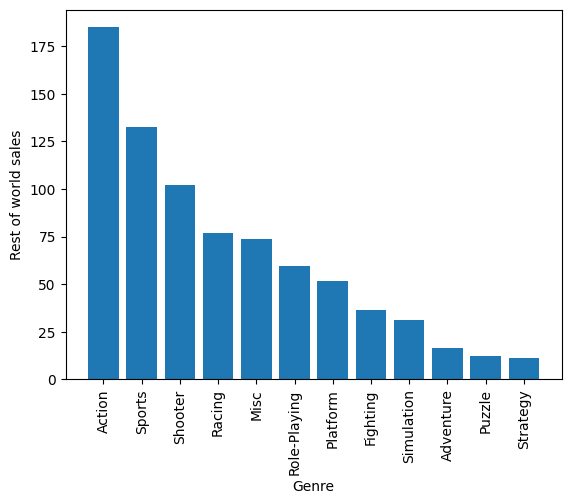

In [10]:
genre_sales_rest=df.groupby("Genre")["Other_Sales"].sum()
genre_sales_rest=genre_sales_rest.sort_values(ascending=False)
print(genre_sales_rest)
plt.bar(genre_sales_rest.index,genre_sales_rest.values)
plt.xticks(rotation=90)
plt.xlabel("Genre")
plt.ylabel("Rest of world sales")
plt.show()

In [19]:
publisher_sales_japan=df.groupby("Publisher")["JP_Sales"].sum()
publisher_sales_japan=publisher_sales_japan.sort_values(ascending=False)
publisher_sales_japan=pd.DataFrame(publisher_sales_japan)
publisher_sales_japan=publisher_sales_japan.reset_index()
publisher_sales_japan=publisher_sales_japan[publisher_sales_japan["JP_Sales"]>0]
pd.set_option('display.max_rows', None)
print(publisher_sales_japan)


                                  Publisher  JP_Sales
0                                  Nintendo    454.99
1                        Namco Bandai Games    126.84
2              Konami Digital Entertainment     90.93
3               Sony Computer Entertainment     74.10
4                                    Capcom     67.38
5                                      Sega     56.19
6                               Square Enix     49.79
7                                SquareSoft     40.13
8                          Enix Corporation     32.40
9                                Tecmo Koei     29.21
10                              Hudson Soft     19.21
11                                Banpresto     16.44
12                          Electronic Arts     13.98
13                                  Level 5     11.65
14                                    Atari     10.70
15                      ASCII Entertainment      9.40
16                       Virgin Interactive      8.94
17                          

Japan people are more willing to buy Nintendo publisher games followed by Namco Bandai Games ,Konami Digital Entertainment publisher games

In [20]:
publisher_sales_NA=df.groupby("Publisher")["NA_Sales"].sum()
publisher_sales_NA=publisher_sales_NA.sort_values(ascending=False)
publisher_sales_NA=pd.DataFrame(publisher_sales_NA)
publisher_sales_NA=publisher_sales_NA.reset_index()
publisher_sales_NA=publisher_sales_NA[publisher_sales_NA["NA_Sales"]>0]
print(publisher_sales_NA)

                                  Publisher  NA_Sales
0                                  Nintendo    815.75
1                           Electronic Arts    584.22
2                                Activision    426.01
3               Sony Computer Entertainment    265.22
4                                   Ubisoft    252.81
5                      Take-Two Interactive    220.47
6                                       THQ    208.60
7                    Microsoft Game Studios    155.35
8                                      Sega    108.78
9                                     Atari    101.23
10             Konami Digital Entertainment     88.91
11                                   Capcom     78.45
12   Warner Bros. Interactive Entertainment     75.34
13               Disney Interactive Studios     70.44
14                       Namco Bandai Games     69.38
15                              Square Enix     48.59
16                                LucasArts     48.43
17                        Ei

North america people more willing to buy Nintendo publisher games followed by Electronic Arts ,Activision publishers

In [21]:
publisher_sales_EU=df.groupby("Publisher")["EU_Sales"].sum()
publisher_sales_EU=publisher_sales_EU.sort_values(ascending=False)
publisher_sales_EU=pd.DataFrame(publisher_sales_EU)
publisher_sales_EU=publisher_sales_EU.reset_index()
publisher_sales_EU=publisher_sales_EU[publisher_sales_EU["EU_Sales"]>0]
print(publisher_sales_EU)

                                  Publisher  EU_Sales
0                                  Nintendo    418.30
1                           Electronic Arts    367.38
2                                Activision    213.72
3               Sony Computer Entertainment    187.55
4                                   Ubisoft    163.03
5                      Take-Two Interactive    117.95
6                                       THQ     94.60
7                                      Sega     81.41
8              Konami Digital Entertainment     68.62
9                    Microsoft Game Studios     68.61
10   Warner Bros. Interactive Entertainment     48.83
11                       Namco Bandai Games     42.61
12                                   Capcom     39.16
13                        Eidos Interactive     34.85
14               Disney Interactive Studios     34.36
15                              Square Enix     32.57
16                       Bethesda Softworks     30.48
17                          

In [27]:
Top_100=df.head(100)
Top_100.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          100 non-null    int64  
 1   Name          100 non-null    object 
 2   Platform      100 non-null    object 
 3   Year          100 non-null    float64
 4   Genre         100 non-null    object 
 5   Publisher     100 non-null    object 
 6   NA_Sales      100 non-null    float64
 7   EU_Sales      100 non-null    float64
 8   JP_Sales      100 non-null    float64
 9   Other_Sales   100 non-null    float64
 10  Global_Sales  100 non-null    float64
dtypes: float64(6), int64(1), object(4)
memory usage: 9.4+ KB


Europe also almost following same trend of north america people

In [28]:
Top_100["Publisher"].value_counts()

,count
Publisher,
Nintendo,52
Activision,14
Take-Two Interactive,9
Sony Computer Entertainment,8
Microsoft Game Studios,6
Electronic Arts,5
Ubisoft,2
Bethesda Softworks,1
Sega,1


Nintendo publisher ranks top it as 52 games ranks under 100 followed by Activision


other additional informaton

In [29]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,8290.190228,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,5.832412,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [41]:
a=df.loc[df["Global_Sales"].idxmax()]
b=df.loc[df["EU_Sales"].idxmax()]
c=df.loc[df["NA_Sales"].idxmax()]
d=df.loc[df["JP_Sales"].idxmax()]
e=df.loc[df["Other_Sales"].idxmax()]
print(a)

Rank                     1
Name            Wii Sports
Platform               Wii
Year                2006.0
Genre               Sports
Publisher         Nintendo
NA_Sales             41.49
EU_Sales             29.02
JP_Sales              3.77
Other_Sales           8.46
Global_Sales         82.74
Name: 0, dtype: object


In [42]:
print(b)

Rank                     1
Name            Wii Sports
Platform               Wii
Year                2006.0
Genre               Sports
Publisher         Nintendo
NA_Sales             41.49
EU_Sales             29.02
JP_Sales              3.77
Other_Sales           8.46
Global_Sales         82.74
Name: 0, dtype: object


In [43]:
print(c)

Rank                     1
Name            Wii Sports
Platform               Wii
Year                2006.0
Genre               Sports
Publisher         Nintendo
NA_Sales             41.49
EU_Sales             29.02
JP_Sales              3.77
Other_Sales           8.46
Global_Sales         82.74
Name: 0, dtype: object


In [44]:
print(d)

Rank                                   5
Name            Pokemon Red/Pokemon Blue
Platform                              GB
Year                              1996.0
Genre                       Role-Playing
Publisher                       Nintendo
NA_Sales                           11.27
EU_Sales                            8.89
JP_Sales                           10.22
Other_Sales                          1.0
Global_Sales                       31.37
Name: 4, dtype: object


In [45]:
print(e)

Rank                                       18
Name            Grand Theft Auto: San Andreas
Platform                                  PS2
Year                                   2004.0
Genre                                  Action
Publisher                Take-Two Interactive
NA_Sales                                 9.43
EU_Sales                                  0.4
JP_Sales                                 0.41
Other_Sales                             10.57
Global_Sales                            20.81
Name: 17, dtype: object


Wii sports is most selled video game .It is the most selled video game in Europe and north america .The most selled game in japan is Pokemon Red/Pokemon Blue. The most selled in remaining all over places in the world is Grand Theft Auto: San Andreas